In [58]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from scipy.stats.mstats import winsorize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

In [59]:
import warnings
warnings.filterwarnings("ignore")

In [60]:
df = pd.read_csv(r'C:\Users\juman\OneDrive\Desktop\Prog\car_price_prediction.csv.zip')

In [61]:
#The data is about car price prediction, the target (y) is the price
# Using Regression

In [62]:
df.head(20)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
5,45802912,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,4.0,Automatic,Front,04-May,Left wheel,White,4
6,45656768,1803,761,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,4.0,Automatic,Front,04-May,Left wheel,White,12
7,45816158,549,751,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,216118 km,4.0,Automatic,Front,04-May,Left wheel,Grey,12
8,45641395,1098,394,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069 km,4.0,Automatic,Front,04-May,Left wheel,Black,12
9,45756839,26657,-,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12


In [63]:
df = df.drop(["ID","Color","Wheel" ,"Airbags","Cylinders","Doors"], axis=1)

In [64]:
df

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,Automatic,4x4
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,Tiptronic,4x4
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,Variator,Front
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,Automatic,4x4
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,Automatic,Front
...,...,...,...,...,...,...,...,...,...,...,...,...
19232,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,Manual,Rear
19233,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,Tiptronic,Front
19234,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,Automatic,Front
19235,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,Automatic,Front


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Price             19237 non-null  int64 
 1   Levy              19237 non-null  object
 2   Manufacturer      19237 non-null  object
 3   Model             19237 non-null  object
 4   Prod. year        19237 non-null  int64 
 5   Category          19237 non-null  object
 6   Leather interior  19237 non-null  object
 7   Fuel type         19237 non-null  object
 8   Engine volume     19237 non-null  object
 9   Mileage           19237 non-null  object
 10  Gear box type     19237 non-null  object
 11  Drive wheels      19237 non-null  object
dtypes: int64(2), object(10)
memory usage: 1.8+ MB


In [66]:
df.duplicated().sum()

np.int64(3542)

In [67]:
df=df.drop_duplicates()

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.isnull().sum()

Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Gear box type       0
Drive wheels        0
dtype: int64

In [70]:
df.head(20)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,Automatic,4x4
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,Tiptronic,4x4
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,Variator,Front
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,Automatic,4x4
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,Automatic,Front
5,39493,891,HYUNDAI,Santa FE,2016,Jeep,Yes,Diesel,2,160931 km,Automatic,Front
6,1803,761,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,258909 km,Automatic,Front
7,549,751,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,216118 km,Automatic,Front
8,1098,394,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,398069 km,Automatic,Front
9,26657,-,LEXUS,RX 350,2007,Jeep,Yes,Petrol,3.5,128500 km,Automatic,4x4


In [71]:
df["Engine volume"] = pd.to_numeric(df["Engine volume"].str.replace(" Turbo", ""), errors="coerce")

In [72]:
df["Mileage"] = pd.to_numeric(df["Mileage"].str.replace(" km", ""), errors="coerce")

In [73]:
df["Levy"] = pd.to_numeric(df["Levy"], errors="coerce")

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15695 entries, 0 to 19236
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             15695 non-null  int64  
 1   Levy              10019 non-null  float64
 2   Manufacturer      15695 non-null  object 
 3   Model             15695 non-null  object 
 4   Prod. year        15695 non-null  int64  
 5   Category          15695 non-null  object 
 6   Leather interior  15695 non-null  object 
 7   Fuel type         15695 non-null  object 
 8   Engine volume     15695 non-null  float64
 9   Mileage           15695 non-null  int64  
 10  Gear box type     15695 non-null  object 
 11  Drive wheels      15695 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 1.6+ MB


In [75]:
df

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,Automatic,4x4
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,Tiptronic,4x4
2,8467,NaN,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,Variator,Front
3,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,Automatic,4x4
4,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,Automatic,Front
...,...,...,...,...,...,...,...,...,...,...,...,...
19230,470,645.0,TOYOTA,Prius,2011,Hatchback,Yes,Hybrid,1.8,307325,Automatic,Front
19232,8467,NaN,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0,300000,Manual,Rear
19233,15681,831.0,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600,Tiptronic,Front
19234,26108,836.0,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2.0,116365,Automatic,Front


In [76]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

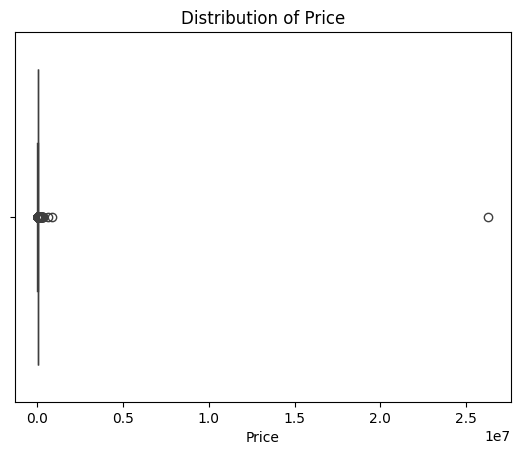

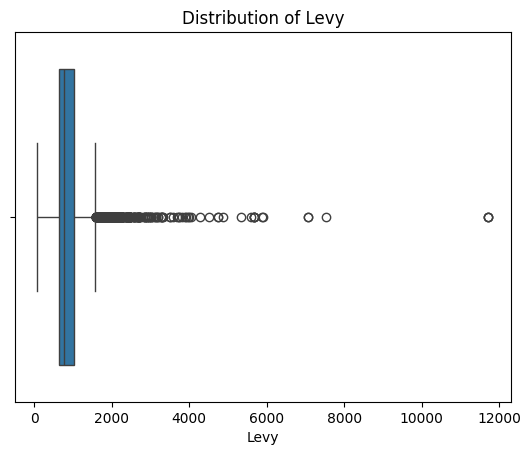

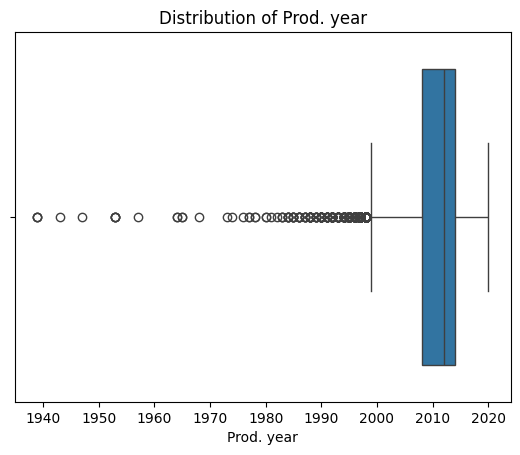

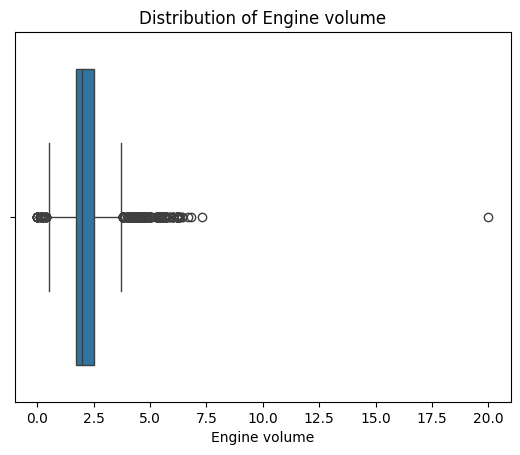

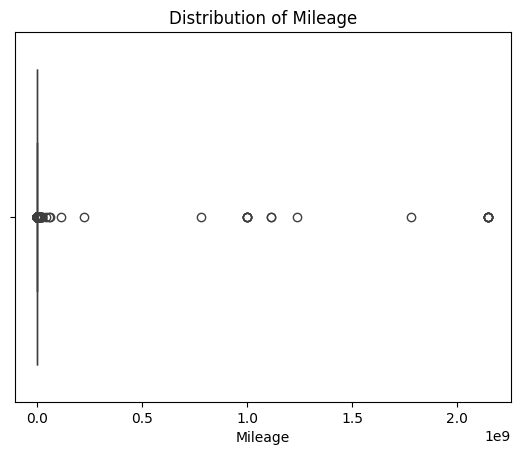

In [77]:
for i in num_cols:
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(f'Distribution of {i}')
    plt.show()

In [78]:
df['Levy'] = df['Levy'].replace('-', pd.NA)
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')

In [79]:
median = SimpleImputer(strategy='median')
df['Levy'] = median.fit_transform(df[['Levy']])

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15695 entries, 0 to 19236
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             15695 non-null  int64  
 1   Levy              15695 non-null  float64
 2   Manufacturer      15695 non-null  object 
 3   Model             15695 non-null  object 
 4   Prod. year        15695 non-null  int64  
 5   Category          15695 non-null  object 
 6   Leather interior  15695 non-null  object 
 7   Fuel type         15695 non-null  object 
 8   Engine volume     15695 non-null  float64
 9   Mileage           15695 non-null  int64  
 10  Gear box type     15695 non-null  object 
 11  Drive wheels      15695 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 1.6+ MB


In [81]:
Q1 = df['Prod. year'].quantile(0.25)
Q3 = df['Prod. year'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Prod. year']<lower) | (df['Prod. year']>upper)
print(df['IQR_Outlier'].sum())

756


In [82]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Price']<lower) | (df['Price']>upper)
print(df['IQR_Outlier'].sum())

946


In [83]:
Q1 = df['Levy'].quantile(0.25)
Q3 = df['Levy'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Levy']<lower) | (df['Levy']>upper)
print(df['IQR_Outlier'].sum())

3696


In [84]:
Q1 = df['Engine volume'].quantile(0.25)
Q3 = df['Engine volume'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Engine volume']<lower) | (df['Engine volume']>upper)
print(df['IQR_Outlier'].sum())

711


In [85]:
Q1 = df['Mileage'].quantile(0.25)
Q3 = df['Mileage'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Mileage']<lower) | (df['Mileage']>upper)
print(df['IQR_Outlier'].sum())

505


In [86]:
df['Price'] = winsorize(df['Price'],limits=[0.05,0.25])
df['Levy'] = winsorize(df['Levy'],limits=[0.05,0.25])
df['Prod. year'] = winsorize(df['Prod. year'],limits=[0.05,0.25])
df['Engine volume'] = winsorize(df['Engine volume'],limits=[0.05,0.25])
df['Mileage'] = winsorize(df['Mileage'],limits=[0.05,0.25])

In [87]:
#After Handling Outliers 
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Price']<lower) | (df['Price']>upper)
print(df['IQR_Outlier'].sum())

0


In [88]:
Q1 = df['Engine volume'].quantile(0.25)
Q3 = df['Engine volume'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Engine volume']<lower) | (df['Engine volume']>upper)
print(df['IQR_Outlier'].sum())

0


In [89]:
Q1 = df['Levy'].quantile(0.25)
Q3 = df['Levy'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Levy']<lower) | (df['Levy']>upper)
print(df['IQR_Outlier'].sum())

1317


In [90]:
Q1 = df['Prod. year'].quantile(0.25)
Q3 = df['Prod. year'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Prod. year']<lower) | (df['Prod. year']>upper)
print(df['IQR_Outlier'].sum())

0


In [91]:
Q1 = df['Mileage'].quantile(0.25)
Q3 = df['Mileage'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper =  Q3+1.5*IQR
df['IQR_Outlier'] = (df['Mileage']<lower) | (df['Mileage']>upper)
print(df['IQR_Outlier'].sum())

0


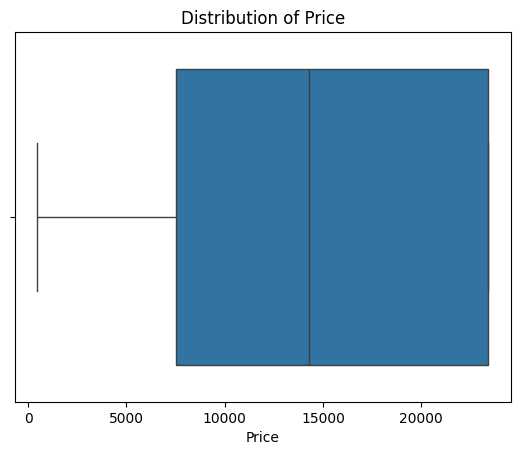

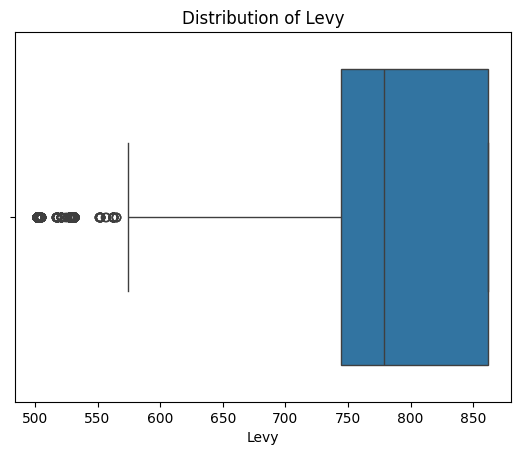

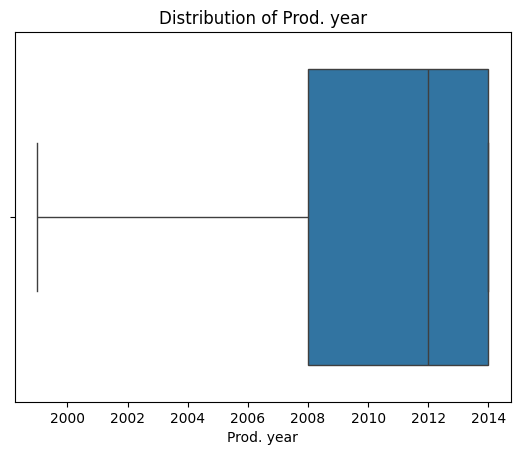

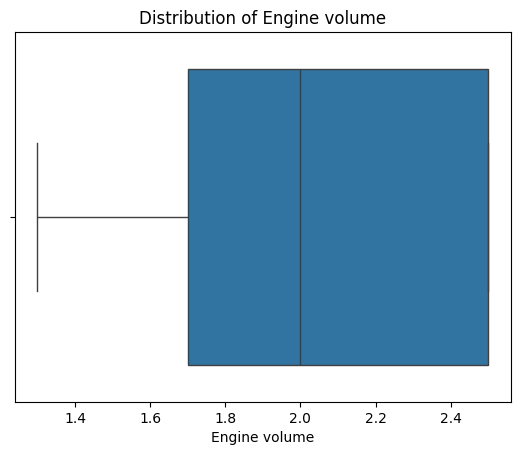

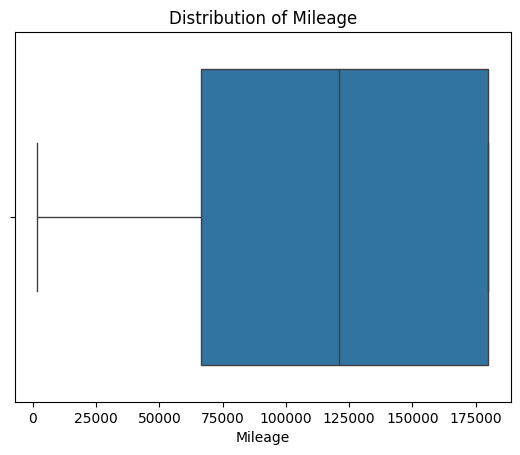

In [92]:
#Visualization after Handling Outliers
for i in num_cols:
    plt.figure()
    sns.boxplot(x=df[i])
    plt.title(f'Distribution of {i}')
    plt.show()

In [93]:
df.head(20)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,IQR_Outlier
0,13328,862.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,2.5,180000,Automatic,4x4,False
1,16621,862.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,2.5,180000,Tiptronic,4x4,False
2,8467,779.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,180000,Variator,Front,False
3,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,Automatic,4x4,False
4,11726,502.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,Automatic,Front,False
5,23414,862.0,HYUNDAI,Santa FE,2014,Jeep,Yes,Diesel,2.0,160931,Automatic,Front,False
6,1803,761.0,TOYOTA,Prius,2010,Hatchback,Yes,Hybrid,1.8,180000,Automatic,Front,False
7,549,751.0,HYUNDAI,Sonata,2013,Sedan,Yes,Petrol,2.4,180000,Automatic,Front,False
8,1098,502.0,TOYOTA,Camry,2014,Sedan,Yes,Hybrid,2.5,180000,Automatic,Front,False
9,23414,779.0,LEXUS,RX 350,2007,Jeep,Yes,Petrol,2.5,128500,Automatic,4x4,False


In [94]:
df.isnull().sum()

Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Gear box type       0
Drive wheels        0
IQR_Outlier         0
dtype: int64

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15695 entries, 0 to 19236
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             15695 non-null  int64  
 1   Levy              15695 non-null  float64
 2   Manufacturer      15695 non-null  object 
 3   Model             15695 non-null  object 
 4   Prod. year        15695 non-null  int64  
 5   Category          15695 non-null  object 
 6   Leather interior  15695 non-null  object 
 7   Fuel type         15695 non-null  object 
 8   Engine volume     15695 non-null  float64
 9   Mileage           15695 non-null  int64  
 10  Gear box type     15695 non-null  object 
 11  Drive wheels      15695 non-null  object 
 12  IQR_Outlier       15695 non-null  bool   
dtypes: bool(1), float64(2), int64(3), object(7)
memory usage: 1.6+ MB


In [96]:
df = df.drop("IQR_Outlier",axis=1)

In [97]:
cat_cols

['Manufacturer',
 'Model',
 'Category',
 'Leather interior',
 'Fuel type',
 'Gear box type',
 'Drive wheels']

In [98]:
ohe = OneHotEncoder(sparse_output=False)

In [99]:
cat_cols

['Manufacturer',
 'Model',
 'Category',
 'Leather interior',
 'Fuel type',
 'Gear box type',
 'Drive wheels']

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15695 entries, 0 to 19236
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             15695 non-null  int64  
 1   Levy              15695 non-null  float64
 2   Manufacturer      15695 non-null  object 
 3   Model             15695 non-null  object 
 4   Prod. year        15695 non-null  int64  
 5   Category          15695 non-null  object 
 6   Leather interior  15695 non-null  object 
 7   Fuel type         15695 non-null  object 
 8   Engine volume     15695 non-null  float64
 9   Mileage           15695 non-null  int64  
 10  Gear box type     15695 non-null  object 
 11  Drive wheels      15695 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 1.6+ MB


In [101]:
encoded = ohe.fit_transform(df[cat_cols])
df[ohe.get_feature_names_out(cat_cols)] = encoded

In [102]:
X = df.drop("Price", axis=1)   # features
y = df["Price"]               # target

In [103]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [104]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [105]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [106]:
X_processed = preprocessor.fit_transform(X)

In [107]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [108]:
linear_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('Regressorr' , LinearRegression())
])

In [109]:
linear_reg_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('Regressorr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [110]:
y_pred_linear = linear_reg_pipeline.predict(X_test)

In [111]:
MSE = mean_squared_error(y_test, y_pred_linear)
MAE = mean_absolute_error(y_test, y_pred_linear)
r2 = r2_score(y_test, y_pred_linear)
print(f"MSE: {MSE}")
print(f"MAE: {MAE}")
print(f"r2 score: {r2}")

MSE: 37922592.82143328
MAE: 4796.897362199201
r2 score: 0.39805112016729693


In [112]:
Decision_tree_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('Decision Tree Regressor' ,DecisionTreeRegressor())
])

In [113]:
Decision_tree_reg_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('Decision Tree Regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [114]:
y_pred_tree = Decision_tree_reg_pipeline.predict(X_test)

In [115]:
MSE = mean_squared_error(y_test, y_pred_tree)
MAE = mean_absolute_error(y_test, y_pred_tree)
r2 = r2_score(y_test, y_pred_tree)
print(f"MSE: {MSE}")
print(f"MAE: {MAE}")
print(f"r2 score: {r2}")

MSE: 44829868.96941304
MAE: 3890.3122161784136
r2 score: 0.28841127672226674
